# Shallow Neural Network

### Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('vehicle_maintenance_data.csv')
df.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,11/23/2023,6/24/2025,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,9/21/2023,6/4/2025,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,6/27/2023,4/27/2025,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,8/24/2023,11/5/2025,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,5/25/2023,9/14/2025,Third,16446,6,2,16.977483,Good,Good,Weak,1


In [2]:
df['Last_Service_Date'] = pd.to_datetime(df['Last_Service_Date'])
df['Warranty_Expiry_Date'] = pd.to_datetime(df['Warranty_Expiry_Date'])

In [3]:
df[['Service_History', 'Accident_History', 'Reported_Issues']]
df['Hist_Record'] = (df['Service_History'] + df['Accident_History'] + df['Reported_Issues']) /  3

df_updated = df.copy()

df_updated.drop(columns= ['Service_History', 'Accident_History', 'Reported_Issues'], axis= 1, inplace= True)

df_updated.head()

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Hist_Record
0,Truck,58765,Good,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,13.622204,New,New,Weak,1,3.000000
1,Van,60353,Average,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,13.625307,New,New,Weak,1,2.666667
2,Bus,68072,Poor,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,14.306302,New,Good,Weak,1,2.333333
3,Bus,60849,Average,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,18.709467,New,Worn Out,New,1,4.666667
4,Bus,45742,Poor,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,16.977483,Good,Good,Weak,1,4.333333


In [4]:
object_col = []

for i in df_updated.columns:
    if df[i].dtype == 'object':
        object_col.append(i)

encoder = LabelEncoder()

for encoded in object_col:
    df_updated[encoded] = encoder.fit_transform(df_updated[encoded])

df_updated

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Hist_Record
0,4,58765,1,4,1,0,2000,28524,2023-11-23,2025-06-24,1,20782,13.622204,1,1,2,1,3.000000
1,5,60353,0,7,1,0,2500,133630,2023-09-21,2025-06-04,1,23489,13.625307,1,1,2,1,2.666667
2,0,68072,2,2,1,0,1500,34022,2023-06-27,2025-04-27,0,17979,14.306302,1,0,2,1,2.333333
3,0,60849,0,5,2,0,2500,81636,2023-08-24,2025-11-05,1,6220,18.709467,1,2,1,1,4.666667
4,0,45742,2,1,2,1,2000,97162,2023-05-25,2025-09-14,2,16446,16.977483,0,0,2,1,4.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,1,77229,1,6,0,0,2500,97404,2023-11-24,2025-09-15,2,5217,10.357298,1,0,2,1,2.666667
49996,4,54742,1,4,0,1,800,13421,2023-07-14,2025-01-21,1,15856,14.924022,2,1,0,1,3.000000
49997,5,75601,2,4,1,0,1500,124851,2023-09-09,2024-11-09,0,6019,19.859243,2,2,2,1,3.333333
49998,1,66181,1,7,1,1,2500,103182,2023-08-26,2025-05-22,2,5030,10.720555,1,0,2,1,2.666667


In [5]:
df_updated['service_status'] = df_updated['Tire_Condition'] + df_updated['Brake_Condition'] + df_updated['Battery_Status'] / 3

df_updated.drop(columns=['Tire_Condition', 'Brake_Condition', 'Battery_Status'], inplace= True, axis = 1)

df_updated.head(2)

,Vehicle_Model,Mileage,Maintenance_History,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,Hist_Record,service_status
0,4,58765,1,4,1,0,2000,28524,2023-11-23,2025-06-24,1,20782,13.622204,1,3.000000,2.666667
1,5,60353,0,7,1,0,2500,133630,2023-09-21,2025-06-04,1,23489,13.625307,1,2.666667,2.666667


In [6]:
df_updated['miles_per_year'] = df_updated['Mileage'] / df['Vehicle_Age']

df_updated.drop(columns=['Mileage', 'Vehicle_Age'], inplace= True, axis= 1)

df_updated.describe()

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,Hist_Record,service_status,miles_per_year
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.503700,0.996800,0.99884,0.500180,1556.292000,75551.187060,2023-09-13 10:33:48.096000,2025-04-11 15:56:30.336000256,1.002700,17465.340700,14.990323,0.809960,3.171513,2.335213,16135.339941
min,0.000000,0.000000,0.00000,0.000000,800.000000,1001.000000,2023-03-30 00:00:00,2024-04-28 00:00:00,0.000000,5000.000000,10.000098,0.000000,0.333333,0.000000,3000.500000
25%,1.000000,0.000000,0.00000,0.000000,1000.000000,38009.000000,2023-06-21 00:00:00,2024-10-18 00:00:00,0.000000,11189.750000,12.489037,1.000000,2.333333,1.333333,6780.325000
50%,3.000000,1.000000,1.00000,1.000000,1500.000000,75598.500000,2023-09-14 00:00:00,2025-04-12 00:00:00,1.000000,17477.500000,14.986352,1.000000,3.333333,2.333333,10030.166667
75%,4.000000,2.000000,2.00000,1.000000,2000.000000,112999.500000,2023-12-06 00:00:00,2025-10-04 00:00:00,2.000000,23692.000000,17.474676,1.000000,4.000000,3.333333,18389.500000
max,5.000000,2.000000,2.00000,1.000000,2500.000000,149999.000000,2024-02-28 00:00:00,2026-03-29 00:00:00,2.000000,30000.000000,19.999968,1.000000,6.000000,4.666667,79990.000000
std,1.711422,0.815943,0.81754,0.500005,627.677218,43088.105658,NaN,NaN,0.813945,7223.393401,2.885583,0.392336,1.176649,1.186846,15588.301259


In [7]:
df_updated['total_hist_service'] = df_updated['Hist_Record'] + df_updated['service_status'] / 2 

df_updated.drop(columns=['Hist_Record', 'service_status'], inplace= True, axis= 1)

In [8]:
df_updated['last_Service_month'] = df_updated['Last_Service_Date'].dt.month
df_updated['Last_Service_Date'].dt.dayofweek.value_counts()

df_updated['week_number'] = df_updated['Last_Service_Date'].dt.isocalendar().week
df_updated.drop(columns=['Last_Service_Date', 'Warranty_Expiry_Date'], axis= 1, inplace= True)

df_updated.head(3)

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Owner_Type,Insurance_Premium,Fuel_Efficiency,Need_Maintenance,miles_per_year,total_hist_service,last_Service_month,week_number
0,4,1,1,0,2000,28524,1,20782,13.622204,1,14691.250000,4.333333,11,47
1,5,0,1,0,2500,133630,1,23489,13.625307,1,8621.857143,4.000000,9,38
2,0,2,1,0,1500,34022,0,17979,14.306302,1,34036.000000,3.166667,6,26


### Modeling


In [9]:
!pip install imbalanced-learn --quiet

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [10]:
X = df_updated.drop(columns='Need_Maintenance', axis = 1)
y = df_updated['Need_Maintenance']

X_temp, X_production, y_temp, y_production = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42, shuffle=True
)

# --- Step 2: Split remaining 60% into train (40%) and val+test (20%) ---
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_temp, y_temp, test_size=0.3333, stratify=y_temp, random_state=42, shuffle=True
)
# 0.3333 * 60% ≈ 20%

# --- Step 3: Split val_test (20%) into val (10%) and test (10%) ---
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, stratify=y_val_test, random_state=42, shuffle=True
)

In [11]:
X_train.head(2)

,Vehicle_Model,Maintenance_History,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Owner_Type,Insurance_Premium,Fuel_Efficiency,miles_per_year,total_hist_service,last_Service_month,week_number
11980,3,2,0,1,2500,81245,0,27555,13.760555,5264.666667,5.166667,2,5
31787,3,1,2,1,2500,148983,1,10139,16.552449,48612.000000,4.500000,4,15


In [12]:
non_binary_col = []
for i in X_train.columns:
    if X_train[i].nunique() != 2:
        non_binary_col.append(i)
print(non_binary_col)

['Vehicle_Model', 'Maintenance_History', 'Fuel_Type', 'Engine_Size', 'Odometer_Reading', 'Owner_Type', 'Insurance_Premium', 'Fuel_Efficiency', 'miles_per_year', 'total_hist_service', 'last_Service_month', 'week_number']


In [13]:
binary_col = []
for i in X_train.columns:
    if X_train[i].nunique() == 2:
        binary_col.append(i)
print(binary_col)

['Transmission_Type']


In [14]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train[non_binary_col])
x_val_scaled = scaler.transform(X_val[non_binary_col])
x_test_scaled = scaler.transform(X_test[non_binary_col])

x_train_scaled

array([[ 2.90236567e-01,  1.22155250e+00, -1.22332238e+00, ...,
         6.28662492e-01, -1.40486029e+00, -1.52677920e+00],
       [ 2.90236567e-01,  1.46403296e-03,  1.22515865e+00, ...,
         1.20508941e-01, -8.21459778e-01, -8.55470139e-01],
       [-1.46090116e+00,  1.46403296e-03,  1.22515865e+00, ...,
         1.26385443e+00, -1.69656055e+00, -1.66104101e+00],
       ...,
       [-2.93476010e-01, -1.21862444e+00, -1.22332238e+00, ...,
        -1.53099010e+00, -1.69656055e+00, -1.79530283e+00],
       [ 1.45766172e+00,  1.22155250e+00,  9.18134482e-04, ...,
        -1.40395171e+00, -8.21459778e-01, -7.88339233e-01],
       [ 8.73949144e-01,  1.46403296e-03, -1.22332238e+00, ...,
         1.39089282e+00, -8.21459778e-01, -8.55470139e-01]])

In [15]:
binary_features_train = X_train[binary_col].astype(float).values
binary_features_val = X_val[binary_col].astype(float).values
binary_features_test = X_test[binary_col].astype(float).values

In [16]:
x_train_full = np.concatenate([x_train_scaled, binary_features_train], axis=1)
x_val_full = np.concatenate([x_val_scaled, binary_features_val], axis=1)
x_test_full = np.concatenate([x_test_scaled, binary_features_test], axis=1)

In [17]:
smote = SMOTE(random_state=42)
x_train_balance, y_train_balanced = smote.fit_resample(x_train_full, y_train)

In [33]:
# prep the test the same way
binary_features_test = X_test[binary_col].astype(float).values
x_test_full = np.concatenate([x_test_scaled, binary_features_test], axis=1)


In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(16, activation='relu', input_shape=(x_train_balance.shape[1],)),
    Dense(1, activation='sigmoid')  # binary output
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_balance, y_train_balanced,
                    validation_data=(x_val_full, y_val),
                    epochs=20,
                    batch_size=32,
                    )

test_loss, test_acc = model.evaluate(x_test_full, y_test)
print(f'Test accuracy: {test_acc:.4f}')


Epoch 1/20


/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1013/1013 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6866 - loss: 0.5870 - val_accuracy: 0.6943 - val_loss: 0.5746
Epoch 2/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7179 - loss: 0.5389 - val_accuracy: 0.6851 - val_loss: 0.5595
Epoch 3/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7234 - loss: 0.5291 - val_accuracy: 0.6863 - val_loss: 0.5444
Epoch 4/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7272 - loss: 0.5246 - val_accuracy: 0.6865 - val_loss: 0.5422
Epoch 5/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7323 - loss: 0.5190 - val_accuracy: 0.6903 - val_loss: 0.5381
Epoch 6/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7348 - loss: 0.5156 - val_accuracy: 0.6961 - val_loss: 0.5350
Epoch 7/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7321 - loss: 0.5158 - val_accuracy: 0.6929 - val_loss: 0.5381
Epoch 8/20
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7320 - loss: 0.5163 - val_accurac

In [35]:
# Predict probabilities on test data
y_pred_probs = model.predict(x_test_full)

# Convert probabilities to class labels
pred = (y_pred_probs >= 0.5).astype(int).flatten()


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


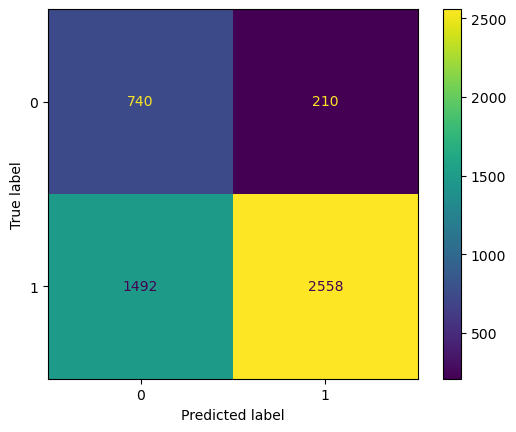

              precision    recall  f1-score   support

           0       0.33      0.78      0.47       950
           1       0.92      0.63      0.75      4050

    accuracy                           0.66      5000
   macro avg       0.63      0.71      0.61      5000
weighted avg       0.81      0.66      0.70      5000



In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Classification report
print(classification_report(y_test, pred))


## Deployment

In [37]:
import tensorflow as tf
import os
import shutil
import tarfile
import sagemaker
from sagemaker.tensorflow.model import TensorFlowModel

In [41]:
# 1) Export the Keras model into “model/” as a SavedModel
model_dir = "model"
model.export(model_dir)   # writes model/saved_model.pb, model/variables/, etc.

# 2) Create a version‐number subfolder “model/1/” and move files in there
version_dir = os.path.join(model_dir, "1")
os.makedirs(version_dir, exist_ok=True)

# Move the SavedModel files into model/1/
for item in os.listdir(model_dir):
    src = os.path.join(model_dir, item)
    if item == "1":
        continue
    dst = os.path.join(version_dir, item)
    shutil.move(src, dst)


INFO:tensorflow:Assets written to: model/assets


INFO:tensorflow:Assets written to: model/assets


Saved artifact at 'model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13), dtype=tf.float32, name='keras_tensor_3')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139930188656528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930188655952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930188655376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139930188654800: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [42]:
import tarfile, os, sagemaker

sess   = sagemaker.Session()
bucket = sess.default_bucket()
prefix = "shallow-nn-model"

archive_name = "model.tar.gz"
with tarfile.open(archive_name, "w:gz") as tar:
    for fn in os.listdir(model_dir):
        tar.add(os.path.join(model_dir, fn), arcname=fn)
print("Packaged:", archive_name)

s3_model_path = sess.upload_data(path=archive_name, bucket=bucket, key_prefix=prefix)
print("Uploaded to S3:", s3_model_path)

Packaged: model.tar.gz
Uploaded to S3: s3://sagemaker-us-east-1-429874041769/shallow-nn-model/model.tar.gz


In [46]:
from sagemaker.tensorflow.model import TensorFlowModel
import sagemaker

sess = sagemaker.Session()
role = sagemaker.get_execution_role()

tf_model = TensorFlowModel(
    model_data=s3_model_path,   # <-- THIS must be an S3 URI to the model.tar.gz
    role=role,
    framework_version=tf.__version__,   # use a TF version SageMaker supports
    sagemaker_session=sess
)

predictor = tf_model.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    endpoint_name="shallow-nn-endpoint"
)
print("Endpoint deployed at:", predictor.endpoint_name)


-----!Endpoint deployed at: shallow-nn-endpoint


## Send real data

In [47]:
# Send one datapoint 
row = X_production.iloc[0]
features = row.values.tolist()
payload = {"instances": [features]}

# Call the endpoint
result = predictor.predict(payload)
print("Raw result:", result)

# Pull the prediction and write in simple terms for the user
pred_value = result["predictions"][0][0]
pred_int = int(pred_value)
if pred_int == 1:
    print("Model says: Needs Maintenance")
else:
    print("Model says: No Maintenance")

Raw result: {'predictions': [[1.0]]}
Model says: Needs Maintenance


## Infrastructure Monitors

In [49]:
import boto3

In [50]:
cloudwatch = boto3.client("cloudwatch")
sns = boto3.client("sns")

resp = sns.list_topics()
for topic in resp["Topics"]:
    print(topic["TopicArn"])


arn:aws:sns:us-east-1:429874041769:RedshiftSNS


In [51]:
ALARM_SNS_TOPIC = "arn:aws:sns:us-east-1:429874041769:MyAlerts"

In [52]:
def create_sagemaker_alarm(endpoint_name: str,
                           metric_name: str,
                           threshold: float,
                           comparison: str,
                           statistic: str = "Average",
                           period: int = 300,
                           evaluation_periods: int = 2,
                           alarm_suffix: str = ""):
    alarm_name = f"{endpoint_name}-{metric_name}{alarm_suffix}"
    cloudwatch.put_metric_alarm(
        AlarmName=alarm_name,
        Namespace="AWS/SageMaker",
        MetricName=metric_name,
        Dimensions=[{"Name":"EndpointName","Value":endpoint_name}],
        Statistic=statistic,
        Period=period,
        EvaluationPeriods=evaluation_periods,
        Threshold=threshold,
        ComparisonOperator=comparison,
        ActionsEnabled=True,
        AlarmActions=[ALARM_SNS_TOPIC],
        TreatMissingData="notBreaching"
    )
    print(f"Created alarm: {alarm_name}")

In [53]:
# CPU Utilization > 80%
create_sagemaker_alarm(
    endpoint_name="shallow-nn-endpoint",
    metric_name="CPUUtilization",
    threshold=80.0,
    comparison="GreaterThanThreshold",
    alarm_suffix="-HighCPU"
)

# Invocation latency > 500 ms
create_sagemaker_alarm(
    endpoint_name="shallow-nn-endpoint",
    metric_name="ModelLatency",
    threshold=500.0,
    comparison="GreaterThanThreshold",
    alarm_suffix="-HighLatency"
)

# 4XX errors > 1 per 5 minutes
create_sagemaker_alarm(
    endpoint_name="shallow-nn-endpoint",
    metric_name="Invocation4xxErrors",
    threshold=1.0,
    comparison="GreaterThanThreshold",
    alarm_suffix="-4XXErrors"
)

Created alarm: shallow-nn-endpoint-CPUUtilization-HighCPU
Created alarm: shallow-nn-endpoint-ModelLatency-HighLatency
Created alarm: shallow-nn-endpoint-Invocation4xxErrors-4XXErrors


## Clean up the session

In [58]:
sess.delete_endpoint_config(endpoint_config_name='shallow-nn-endpoint')
sess.delete_endpoint(endpoint_name='shallow-nn-endpoint')